# Nonparametric Filters: Discrete Bayes Filter & Histogram Filter

## Introduction

In probabilistic robotics, **nonparametric filters** approximate posteriors over continuous state spaces using a finite number of values. Unlike parametric filters (e.g., Kalman filter) that represent beliefs with a fixed functional form (e.g., Gaussian), nonparametric filters make no strong assumptions about the shape of the posterior.

This makes them especially powerful for:
- **Multi-modal beliefs** (the robot thinks it might be in one of several distinct locations)
- **Non-Gaussian uncertainty**
- **Global localization** (the robot has no idea where it is)
- **Nonlinear dynamics and sensors**

This tutorial covers two foundational nonparametric approaches:
1. **Discrete Bayes Filter** — for state spaces that are naturally discrete (or discretized)
2. **Histogram Filter** — applying discrete filter ideas to continuous state spaces by decomposing them into bins

---

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.ndimage import convolve1d
from scipy.stats import norm
import matplotlib.animation as animation
from IPython.display import HTML
from typing import Tuple, Optional

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})
np.random.seed(42)

---

## Part 1: Discrete Bayes Filter

### The Core Idea

The **discrete Bayes filter** operates on a finite state space $\mathcal{X} = \{x_1, x_2, \dots, x_N\}$. The belief $\mathbf{bel}(x)$ is a probability mass function — a vector of $N$ probabilities that sum to 1.

At each time step $t$, we apply two steps:

**1. Prediction step** (motion model):
$$\overline{\mathbf{bel}}(x) = \sum_{x'} p(x \mid x', u_t) \; \mathbf{bel}(x')$$

**2. Update step** (measurement model):
$$\mathbf{bel}(x) = \eta \; p(z_t \mid x) \; \overline{\mathbf{bel}}(x)$$

where $\eta$ is a normalizer ensuring $\sum_x \mathbf{bel}(x) = 1$.

### Example: 1D Robot in a Corridor with Doors

Consider a robot moving along a 1D corridor of length 10 meters. The corridor has
three doors at positions 1.5, 5.0, and 8.0 meters. The robot:
- Moves right with deterministic commands ($u_t = 0.5$ m per step)
- Has a sensor that detects doors. The measurement likelihood $p(z_t \mid x)$
  is a **trimodal Gaussian** — three Gaussian peaks, one centered at each door:
  $$p(z_t \mid x) \propto \sum_{i=1}^{3} \mathcal{N}(x \mid \text{door}_i, \; \sigma_z^2)$$

This models a sensor that can see doors: if the robot is near *any* door, the
likelihood is high; if the robot is far from all doors, the likelihood is low.
The three peaks have **equal height** — the sensor response is the same at every door.

In [2]:
def create_corridor_world(resolution: float = 0.1) -> dict:
    """Create a 1D corridor world with discrete states.
    
    Args:
        resolution: Size of each discrete bin in meters.
    
    Returns:
        dict with: states (positions), door_map, N (num states), corridor_length
    """
    corridor_length = 10.0  # meters
    door_positions = [1.5, 5.0, 8.0]  # meter positions of doors
    
    states = np.arange(0, corridor_length, resolution)
    N = len(states)
    
    door_map = np.zeros(N, dtype=bool)
    for door in door_positions:
        idx = int(door / resolution)
        door_map[idx] = True
    
    return {
        'states': states,
        'door_map': door_map,
        'N': N,
        'corridor_length': corridor_length,
        'resolution': resolution,
        'door_positions': door_positions
    }

def sense_open(state: float, door_positions, resolution):
    for door in door_positions:
        if abs(state - door) < 3 * resolution:
            return True
    return False

world = create_corridor_world(resolution=0.1)
print(f"Number of discrete states: {world['N']}")
print(f"Resolution: {world['resolution']} m")
print(f"Door positions: {world['door_positions']} m")

Number of discrete states: 100
Resolution: 0.1 m
Door positions: [1.5, 5.0, 8.0] m


### Motion Model

For clarity, we use a **noise-free motion model**: the robot moves exactly $u_t$ meters
to the right on each command. The state transition is deterministic:

$$p(x_t \mid x_{t-1}, u_t) = \begin{cases} 1 & \text{if } x_t = x_{t-1} + u_t \\ 0 & \text{otherwise} \end{cases}$$

With a discrete state space (resolution = 0.1 m), a command $u = 0.5$ m corresponds
to shifting the probability mass by exactly 5 bins to the right. Probability that
would move past the right boundary is accumulated at the rightmost state.

> **Note:** In practice, real robots have noisy motion. We keep motion deterministic
> here to clearly isolate how the *measurement* shapes the belief. The actual robot
> trajectory in our simulation will still include noise for realism.

In [13]:
def build_motion_model(states: np.ndarray, control: float) -> np.ndarray:
    """Build the deterministic state transition matrix P(x_i | x_j, u).
    
    The robot moves exactly `control` meters rightward. Since states are discrete,
    each source state maps to exactly one destination state (shift right by
    control/resolution bins). Mass at the right boundary stays at the boundary.
    
    Args:
        states: Array of discrete state positions.
        control: Exact displacement (positive = rightward).
    
    Returns:
        (N, N) stochastic matrix where column j has a single 1 at row i
        corresponding to states[j] + control (clamped to max index).
    """
    N = len(states)
    resolution = states[1] - states[0]
    shift_bins = int(round(control / resolution))
    
    A = np.zeros((N, N))
    for j in range(N):
        i = min(j + shift_bins, N - 1)  # destination index, clamped to boundary
        A[i, j] = 1.0
    
    return A


def predict(bel: np.ndarray, control: float, states: np.ndarray) -> np.ndarray:
    """Prediction step: bel_bar = A @ bel (deterministic shift)"""
    A = build_motion_model(states, control)
    bel_bar = A @ bel

    bel_bar[bel_bar == 0] = 1e-3
    bel_bar /= bel_bar.sum()
    
    return bel_bar

### Measurement Model

The measurement likelihood is a **trimodal Gaussian** with three equal-height
peaks, one at each door position:

$$p(z_t \mid x) = \sum_{i=1}^{3} \mathcal{N}\big(x \;\big|\; \text{door}_i, \; \sigma_z^2\big)$$

This models a door-detecting sensor: the probability of the measurement is high
whenever the robot is near a door, and low between doors. Since all three
Gaussians have the same variance and are unweighted, **all three peaks have
identical height** — the sensor cannot distinguish *which* door it sees.

This produces a perfectly trimodal likelihood that clearly demonstrates the
multi-modal nature of the discrete Bayes filter.

In [4]:
def measurement_likelihood(states: np.ndarray,
                           door_positions: np.ndarray,
                           sensor_noise: float = 0.5) -> np.ndarray:
    """Compute trimodal likelihood: sum of 3 equal Gaussians at each door.
    
    p(z | x) = sum_i N(x | door_i, sensor_noise^2)
    Three equal-height peaks at the three door positions.
    
    Args:
        states: Array of discrete state positions.
        door_positions: Positions of the 3 doors.
        sensor_noise: Std of each Gaussian component.
    
    Returns:
        Likelihood vector (trimodal).
    """
    likelihood = np.zeros(len(states))
    for door in door_positions:
        likelihood += norm.pdf(states, loc=door, scale=sensor_noise)
    likelihood /= likelihood.sum()
    
    closed_likelihood = 1 - 0.9 * likelihood
    closed_likelihood /= closed_likelihood.sum()
    return likelihood, closed_likelihood


def update(bel_bar: np.ndarray, states: np.ndarray,
           door_positions: np.ndarray, sensor_noise: float = 0.5, sense_open: bool = False) -> np.ndarray:
    """Update step: bel = eta * p(z|x) * bel_bar"""
    likelihood, closed_likelihood = measurement_likelihood(states, door_positions, sensor_noise)
    if sense_open == True:
        bel = likelihood * bel_bar
    else:
        bel = closed_likelihood * bel_bar
    bel /= bel.sum()
    return bel

### Visualization Helper

In [5]:
def plot_belief(ax, states, belief, door_map, title="Belief", color='C0',
                alpha=0.7, true_pos=None, show_doors=True):
    """Plot a belief distribution over the 1D corridor."""
    ax.clear()
    ax.bar(states, belief, width=world['resolution'], color=color, alpha=alpha, edgecolor='none')
    
    if show_doors:
        door_states = states[door_map]
        door_belief_vals = belief[door_map]
        ax.bar(door_states, door_belief_vals, width=world['resolution'],
               color='C3', alpha=0.6, edgecolor='none', label='Door location')
    
    if true_pos is not None:
        ax.axvline(true_pos, color='C2', linewidth=3, linestyle='--', label=f'True pos = {true_pos:.1f} m')
    
    ax.set_xlabel('Position (m)')
    ax.set_ylabel('Probability')
    ax.set_title(title)
    ax.set_xlim(0, world['corridor_length'])
    if show_doors:
        ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

### Running the Discrete Bayes Filter

Let's simulate a robot moving through the corridor, using the discrete Bayes filter to track its belief.

In [14]:
def simulate_discrete_bayes_filter(
    n_steps: int = 20,
    motion_noise: float = 0.3,
    initial_belief: Optional[np.ndarray] = None
) -> list:
    """Run discrete Bayes filter with trimodal measurement likelihood."""
    states = world['states']
    door_positions = np.array(world['door_positions'])
    resolution = world['resolution']
    sensor_noise = 0.5
    control = 0.5
    
    if initial_belief is None:
        bel = np.ones(world['N']) / world['N']
    else:
        bel = initial_belief.copy()
    true_pos = 0.5
    
    history = [{'step': 0, 'true_pos': true_pos, 'control': 0.0,
                'belief': bel.copy()}]
    
    for t in range(1, n_steps + 1):
        true_pos += control
        true_pos = np.clip(true_pos, 0, world['corridor_length'])
        bel_bar = predict(bel, control, states)
        bel = update(bel_bar, states, door_positions, sensor_noise, sense_open(true_pos, door_positions, resolution))
        history.append({'step': t, 'true_pos': true_pos, 'control': control,
                        'belief': bel.copy()})
    return history


history = simulate_discrete_bayes_filter(n_steps=20)
print(f"Simulated {len(history) - 1} steps.")
print(f"Final true position: {history[-1]['true_pos']:.2f} m")

Simulated 20 steps.
Final true position: 10.00 m


### Visualizing the Belief Evolution

We'll show snapshots at key steps to see how the belief converges.

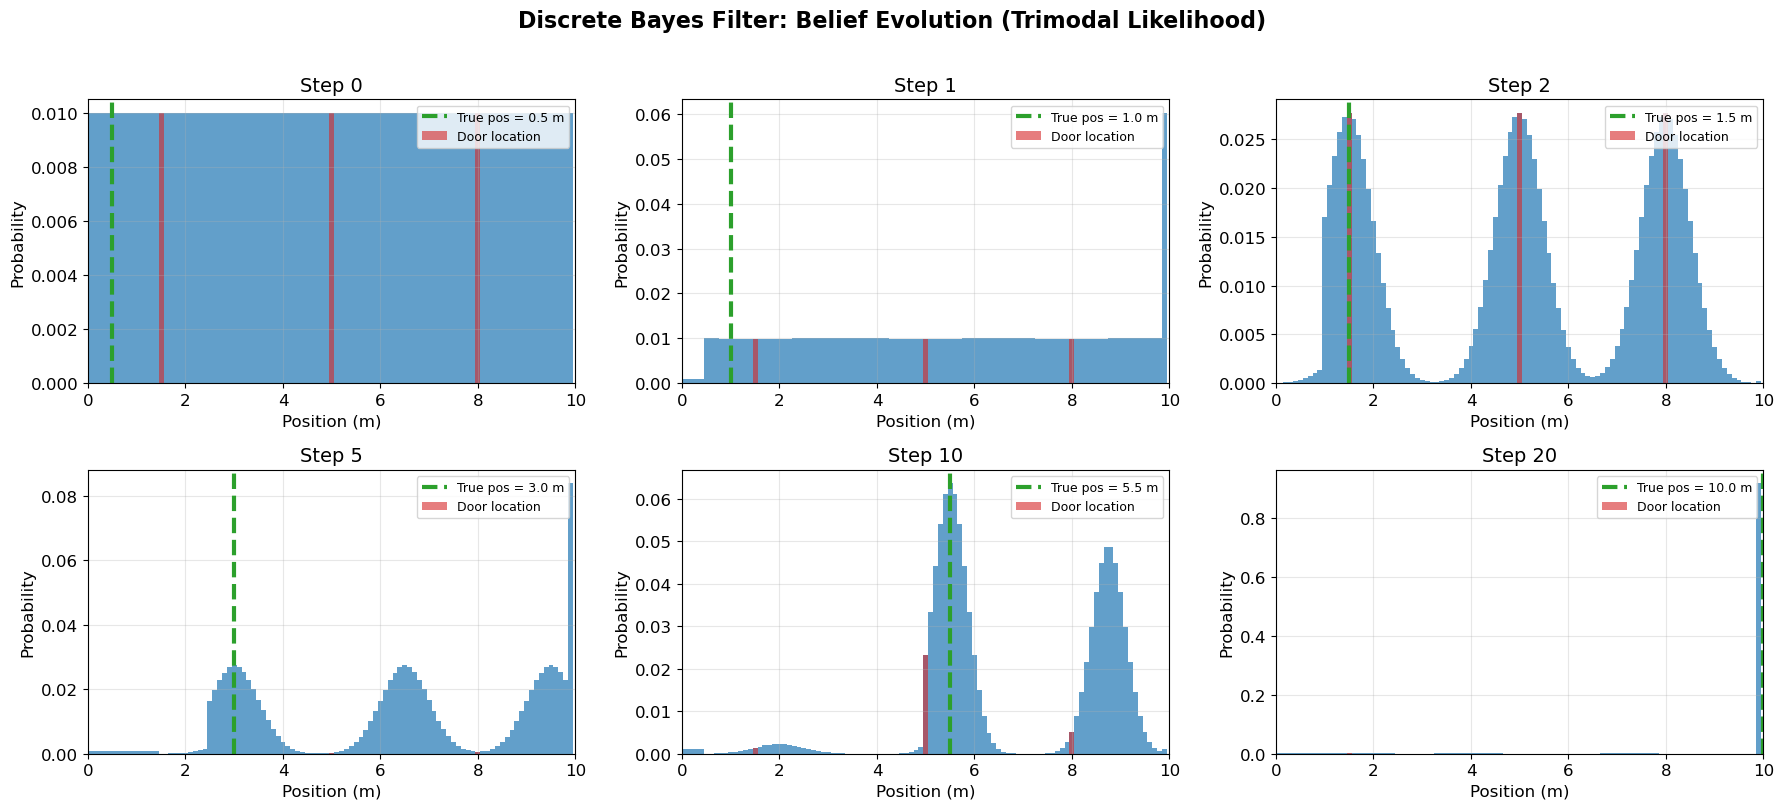

In [15]:
key_steps = [0, 1, 2, 5, 10, 20]
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, step in enumerate(key_steps):
    h = history[step]
    plot_belief(axes[i], world['states'], h['belief'], world['door_map'],
                title=f"Step {step}", true_pos=h['true_pos'])

fig.suptitle('Discrete Bayes Filter: Belief Evolution (Trimodal Likelihood)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---

## Part 2: Histogram Filter

### From Discrete to Histogram

The **histogram filter** discretizes a continuous state space into $K$ bins and
applies the **same models** as the discrete filter:

- **Deterministic motion**: shift probability mass right by $u_t$ bins
- **Trimodal likelihood**: $p(z_t \mid x) = \sum_{i=1}^{3} \mathcal{N}(x \mid \text{door}_i, \sigma_z^2)$
  — three equal-height Gaussian peaks at the door positions

The only difference is that the state space is a continuous interval subdivided
into bins, rather than a set of naturally discrete cells.

### Decomposition Techniques

There are two common decomposition strategies:

**1. Static (Fixed-Resolution) Decomposition** — Divide the state space into equal-width bins.

**2. Dynamic (Adaptive) Decomposition** — Selectively increase resolution where the posterior has high probability mass. Techniques include:
   - Quadtrees / Octrees (for 2D/3D)
   - kd-trees
   - Density trees

The trade-off: finer bins give better accuracy but increase computation.

In [11]:
def histogram_filter_predict(bel: np.ndarray, control: float, bins: np.ndarray) -> np.ndarray:
    """Deterministic prediction: shift belief right by `control` meters."""
    bin_width = bins[1] - bins[0]
    shift_bins = int(round(control / bin_width))
    N = len(bel)
    bel_bar = np.zeros(N)
    for j in range(N):
        i = min(j + shift_bins, N - 1)
        bel_bar[i] += bel[j]

    bel_bar[bel_bar == 0] = 1e-3
    bel_bar /= bel_bar.sum()
    return bel_bar


def histogram_filter_update(bel_bar: np.ndarray, bins: np.ndarray,
                            door_positions: np.ndarray,
                            sensor_noise: float = 0.5, sense_open:bool = False) -> np.ndarray:
    """Update step with trimodal likelihood (same as discrete filter).
    
    p(z | x) = sum_i N(x | door_i, sigma^2)  — three equal-height peaks.
    """
    bin_centers = (bins[:-1] + bins[1:]) / 2
    likelihood = np.zeros(len(bin_centers))
    for door in door_positions:
        likelihood += norm.pdf(bin_centers, loc=door, scale=sensor_noise)

    likelihood /= likelihood.sum()

    closed_likelihood = 1 - 0.9 * likelihood
    closed_likelihood /= closed_likelihood.sum()
    if sense_open == True:
        bel = likelihood * bel_bar
    else:
        bel = closed_likelihood * bel_bar
    bel /= bel.sum()
    return bel

### Running the Histogram Filter

Let's simulate the histogram filter with resolution 0.05 m (200 bins).
Same models as Part 1: deterministic motion + trimodal likelihood:

$$p(z_t \mid x) = \sum_{i=1}^{3} \mathcal{N}(x \mid \text{door}_i, \sigma_z^2)$$

The robot starts at 0.5 m with uniform belief, moves 0.5 m/step.

Simulated 20 steps, 200 bins.
Final true position: 10.00 m


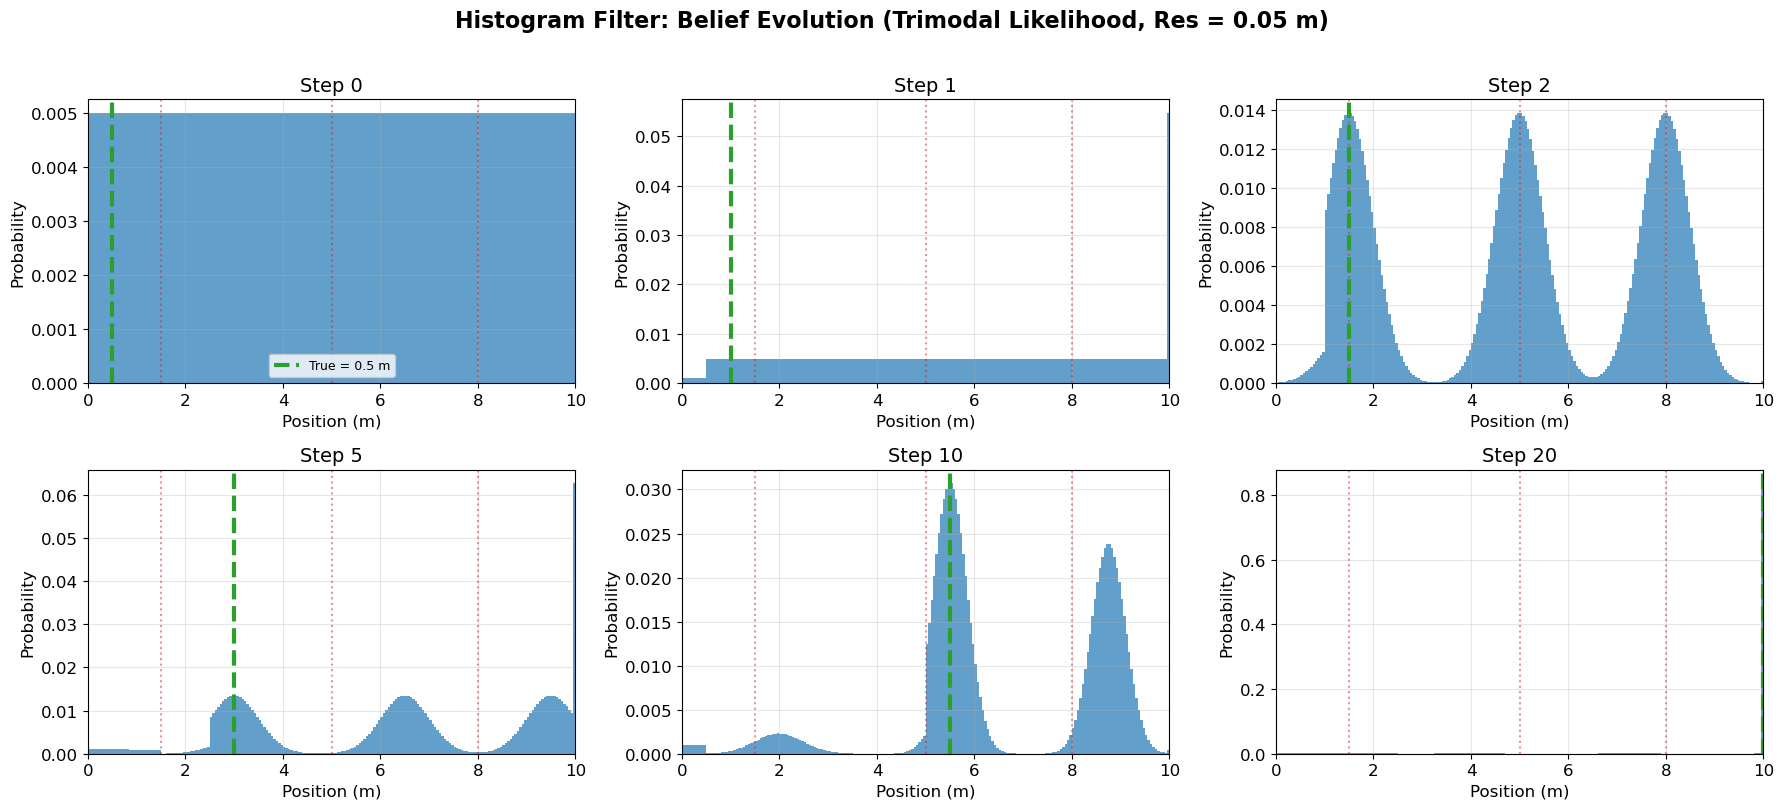

In [12]:
def simulate_histogram_bayes_filter(resolution: float = 0.05, n_steps: int = 20) -> list:
    """Run histogram filter with trimodal likelihood."""
    bins = np.arange(0, 10 + resolution, resolution)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    N = len(bin_centers)
    door_positions = np.array([1.5, 5.0, 8.0])
    sensor_noise = 0.5
    bel = np.ones(N) / N
    true_pos = 0.5
    
    history = [{'step': 0, 'true_pos': true_pos, 'control': 0.0,
                'belief': bel.copy(), 'bin_centers': bin_centers}]
    for t in range(1, n_steps + 1):
        control = 0.5
        actual_move = control
        true_pos += actual_move
        true_pos = np.clip(true_pos, 0, 10)
        bel_bar = histogram_filter_predict(bel, control, bins)
        bel = histogram_filter_update(bel_bar, bins, door_positions, sensor_noise, sense_open(true_pos, door_positions, resolution))
        history.append({'step': t, 'true_pos': true_pos, 'control': control,
                        'belief': bel.copy(), 'bin_centers': bin_centers})
    return history


np.random.seed(42)
hf_history = simulate_histogram_bayes_filter(resolution=0.05, n_steps=20)
print(f"Simulated {len(hf_history) - 1} steps, {len(hf_history[0]['bin_centers'])} bins.")
print(f"Final true position: {hf_history[-1]['true_pos']:.2f} m")

# Plot belief evolution
key_steps = [0, 1, 2, 5, 10, 20]
door_positions = np.array([1.5, 5.0, 8.0])
bin_centers = hf_history[0]['bin_centers']
bin_width = bin_centers[1] - bin_centers[0]
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()
for i, step in enumerate(key_steps):
    h = hf_history[step]
    ax = axes[i]
    ax.bar(bin_centers, h['belief'], width=bin_width, color='C0', alpha=0.7, edgecolor='none')
    for d in door_positions:
        ax.axvline(d, color='C3', linestyle=':', linewidth=1.5, alpha=0.5)
    ax.axvline(h['true_pos'], color='C2', linewidth=3, linestyle='--', label=f'True = {h["true_pos"]:.1f} m')
    ax.set_title(f"Step {step}")
    ax.set_xlabel('Position (m)')
    ax.set_ylabel('Probability')
    ax.set_xlim(0, 10)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=9)
fig.suptitle('Histogram Filter: Belief Evolution (Trimodal Likelihood, Res = 0.05 m)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---

## Summary

### Discrete Bayes Filter
- Belief: probability mass function over $N$ discrete states
- **Predict**: Deterministic shift right by $u_t$ (clamped at boundaries)
- **Update**: $\mathbf{bel}(x) = \eta \; p(z \mid x) \; \overline{\mathbf{bel}}(x)$
- **Trimodal likelihood**: $p(z \mid x) = \sum_i \mathcal{N}(x \mid \text{door}_i, \sigma^2)$
  — three equal-height Gaussian peaks at the doors
- Complexity: $O(N)$ for both steps

### Histogram Filter
- Discretizes continuous space into bins; **identical models** as discrete filter
- **Same deterministic motion** + **same trimodal likelihood**
- Static: equal-width bins, $O(K)$ per step
- Dynamic: adapts resolution where probability is high

### Key Properties
| Property | Parametric | Nonparametric |
|----------|-----------|---------------|
| Belief | Gaussian only | Arbitrary shape |
| Multi-modal | No | Yes (trimodal likelihood) |
| Global localization | Needs guess | Uniform prior works |
| Cost | $O(1)$ | $O(K)$ |

### What's Next?
- **Particle Filters** — Weighted samples for even more flexibility
- **Multi-dimensional grids** — Extend to 2D/3D occupancy grids